        Unnamed: 0       id                     time        variable  value
0                1  AS14.01  2014-02-26 13:00:00.000            mood   6.00
1                2  AS14.01  2014-02-26 15:00:00.000            mood   6.00
2                3  AS14.01  2014-02-26 18:00:00.000            mood   6.00
3                4  AS14.01  2014-02-26 21:00:00.000            mood   7.00
4                5  AS14.01  2014-02-27 09:00:00.000            mood   6.00
...            ...      ...                      ...             ...    ...
376907     2770399  AS14.30  2014-04-11 07:51:16.948  appCat.weather   8.03
376908     2772465  AS14.30  2014-04-19 11:00:32.747  appCat.weather   3.01
376909     2774026  AS14.30  2014-04-26 10:19:07.434  appCat.weather   7.03
376910     2774133  AS14.30  2014-04-27 00:44:48.450  appCat.weather  23.03
376911     2784435  AS14.32  2014-04-07 18:25:14.036  appCat.weather  22.43

[376912 rows x 5 columns]

 --Unique--
         Unnamed: 0   time  variable  value
id  

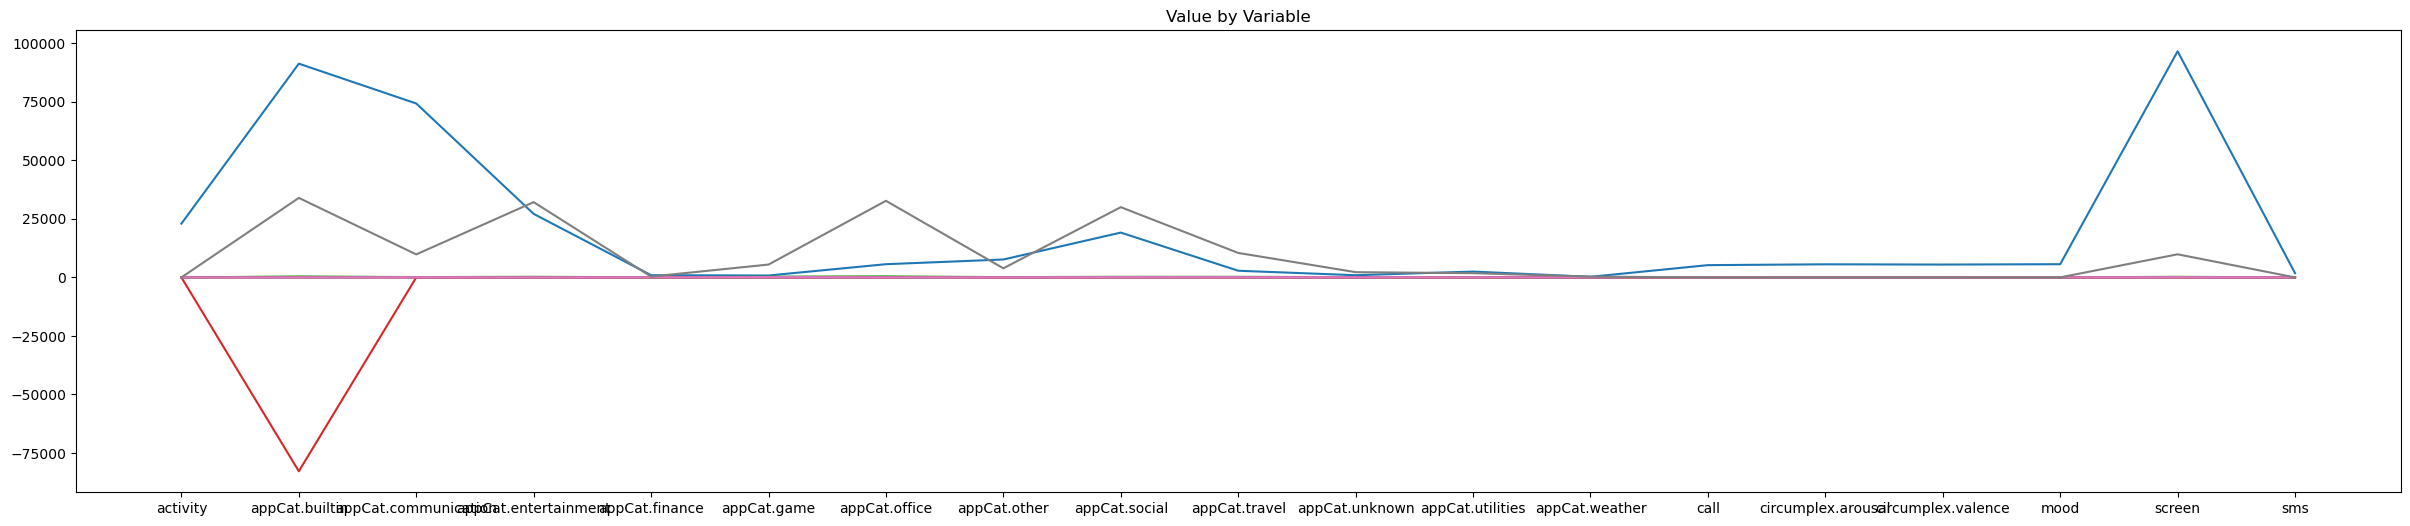

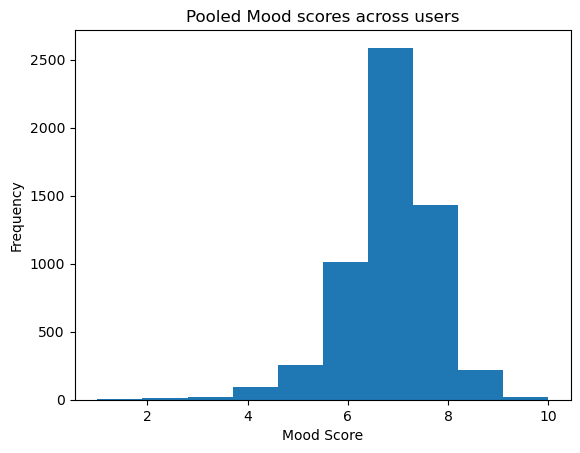

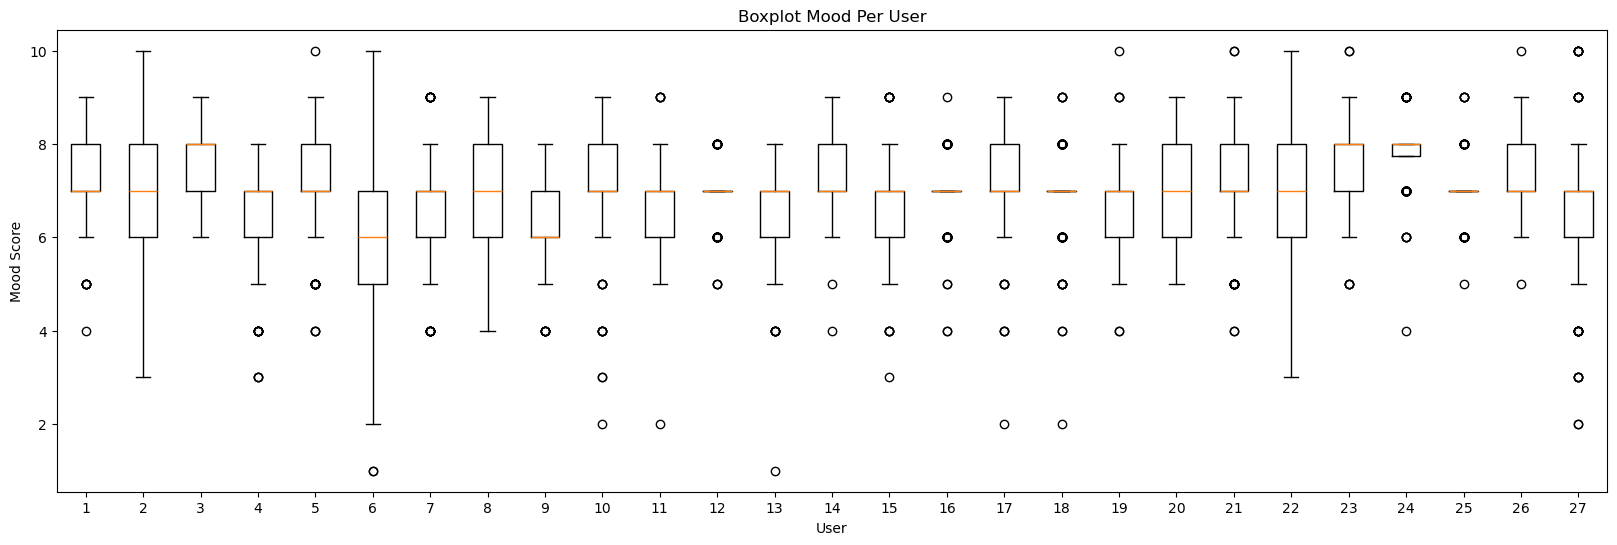

In [2]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mental_health = pd.read_csv("dataset_mood_smartphone.csv")
pd.set_option("display.float_format", lambda x: "%.2f" % x)
print(mental_health)
# print("\n--Info--")
# print(mental_health.info())
# print("\n--Describe--")
# print(mental_health.describe())
# print("\n--IsNull--")
# print(mental_health.isnull().sum())
# print("\n--Unique--")
# print(mental_health.nunique())
# print("\n--Correlation--")
# print(mental_health.corr(numeric_only=True))

df_byVar = mental_health.groupby("variable")["value"].describe()
fig, ax = plt.subplots(figsize=(30, 6))
ax.plot(df_byVar)
ax.set_title("Value by Variable")
fig.savefig("graph.png")

print("\n --Unique--")
print(mental_health.groupby("id").nunique())

df_pooledMood = mental_health[mental_health["variable"] == "mood"]
fig, ax = plt.subplots()
ax.hist(df_pooledMood["value"].values)
ax.set_title("Pooled Mood scores across users")
ax.set_xlabel("Mood Score")
ax.set_ylabel("Frequency")
fig.savefig("pooled_mood_scores.png")

df_moodPerUser = mental_health[mental_health["variable"] == "mood"].groupby("id")[
    "value"
]
fig, ax = plt.subplots(figsize=(20, 6))
ax.boxplot([group.values for _, group in df_moodPerUser])
ax.set_title("Boxplot Mood Per User")
ax.set_xlabel("User")
ax.set_ylabel("Mood Score")
fig.savefig("mood_per_user_boxplot.png")


mental_health["timestamp"] = pd.to_datetime(
    mental_health["time"]
)  # check your actual column name
mental_health["date"] = mental_health["timestamp"].dt.date

# Different aggregation per variable type
mean_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
sum_vars = [
    c
    for c in mental_health["variable"].unique()
    if c.startswith("appCat") or c in ["screen", "call", "sms"]
    ]

mental_health["timestamp"] = pd.to_datetime(mental_health["time"])  # adjust column name
mental_health["date"] = mental_health["timestamp"].dt.date
# moods per user per day
mood_only = mental_health[mental_health["variable"] == "mood"]
print(mood_only.groupby(["id", "date"]).size().describe())
# total span per user
print("\n date span per user")
pd.set_option("display.max_rows", None)
print(mental_health.groupby("id")["date"].agg(["min", "max", "nunique"]))

# Different aggregation per variable type
mean_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']
sum_vars  = [c for c in mental_health['variable'].unique() 
             if c.startswith('appCat') or c in ['screen', 'call', 'sms']]

daily_mean = (mental_health[mental_health['variable'].isin(mean_vars)]
              .groupby(['id', 'date', 'variable'])['value'].mean().unstack())
daily_sum  = (mental_health[mental_health['variable'].isin(sum_vars)]
              .groupby(['id', 'date', 'variable'])['value'].sum().unstack())
daily = daily_mean.join(daily_sum).reset_index()

print(daily_mean)
print(daily_sum)


       mood_daily
count     1268.00
mean         6.99
std          0.74
min          3.00
25%          6.60
50%          7.00
75%          7.50
max          9.33
Number of (user, day) instances with a mood label: 1268


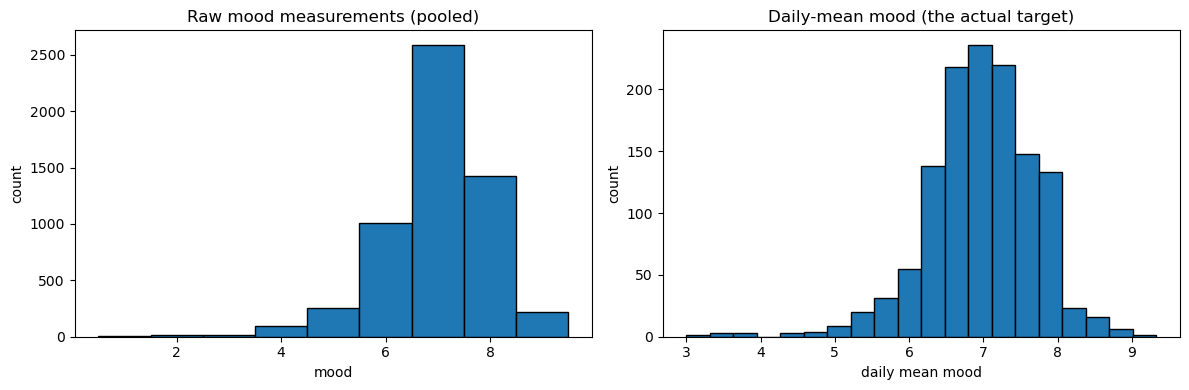

In [12]:
# daily_mood = mood_only.groupby(["id", "date"])
# print(daily_mood.describe())
import numpy as np

daily_mood2 = mood_only.groupby(["id", "date"])["value"].mean().reset_index()
daily_mood2 = daily_mood2.rename(columns={"value": "mood_daily"})
print(daily_mood2.describe())

print(f"Number of (user, day) instances with a mood label: {len(daily_mood2)}")

fig, axes = plt.subplots(1,2,figsize=(12, 4))
axes[0].hist(mood_only["value"], bins=np.arange(1, 11) - 0.5, edgecolor="black")
axes[0].set_title("Raw mood measurements (pooled)")
axes[0].set_xlabel("mood"); axes[0].set_ylabel("count")
axes[1].hist(daily_mood2["mood_daily"], bins=20, edgecolor="black")
axes[1].set_title("Daily-mean mood (the actual target)")
axes[1].set_xlabel("daily mean mood"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

In [19]:
#(2) Instance count: user-days with vs without a mood label
# Build the full grid of (user, day) over each user's observed span
# then see how many of those days actually have a mood

spans = mental_health.groupby("id")["date"].agg(["min", "max"])
print(spans.describe())
all_user_days = []

spans = mental_health.groupby("id")["date"].agg(["min", "max"])
spans["min"] = pd.to_datetime(spans["min"])
spans["max"] = pd.to_datetime(spans["max"])
spans["n_days"] = (spans["max"] - spans["min"]).dt.days + 1
print(spans["n_days"].describe())
print(spans.sort_values("n_days"))

               min         max
count           27          27
unique           5          10
top     2014-02-17  2014-05-05
freq            23          12
count    27.00
mean     79.78
std      10.44
min      50.00
25%      77.50
50%      78.00
75%      81.00
max     104.00
Name: n_days, dtype: float64
               min        max  n_days
id                                   
AS14.07 2014-03-17 2014-05-05      50
AS14.24 2014-04-09 2014-06-09      62
AS14.02 2014-02-17 2014-04-25      68
AS14.12 2014-02-19 2014-05-05      76
AS14.05 2014-02-18 2014-05-05      77
AS14.23 2014-02-17 2014-05-04      77
AS14.13 2014-02-17 2014-05-04      77
AS14.01 2014-02-17 2014-05-05      78
AS14.30 2014-02-17 2014-05-05      78
AS14.20 2014-02-17 2014-05-05      78
AS14.19 2014-02-17 2014-05-05      78
AS14.16 2014-02-17 2014-05-05      78
AS14.17 2014-02-17 2014-05-05      78
AS14.14 2014-02-17 2014-05-05      78
AS14.09 2014-02-17 2014-05-05      78
AS14.08 2014-02-17 2014-05-05      78
AS14.06 2014

####OUTLIERS####
                           min  0.1%    1%     50%      99%    99.9%      max
variable                                                                     
activity                  0.00  0.00  0.00    0.10     0.45     0.55     0.57
circumplex.arousal       -2.00 -2.00 -1.67    0.00     1.36     1.95     2.00
circumplex.valence       -1.25 -1.00 -0.50    0.80     1.50     2.00     2.00
mood                      3.00  3.38  4.80    7.00     8.50     9.00     9.33
appCat.builtin       -80367.93  1.12  8.14  764.74 17481.11 33070.90 40323.88
appCat.communication      1.09  3.01 12.69 2080.11 10286.19 14381.81 20718.75
appCat.entertainment      1.01  1.86  5.14  662.91  6297.59 20182.87 35937.64
appCat.finance            1.00  1.22  3.22   49.38   849.21  1269.32  1321.10
appCat.game               1.01  1.02  2.85  209.75  4771.38 11531.12 12996.49
appCat.office             0.04  0.31  1.02   72.00  5400.41 25786.91 33283.02
appCat.other              2.01  4.13  7.02   65

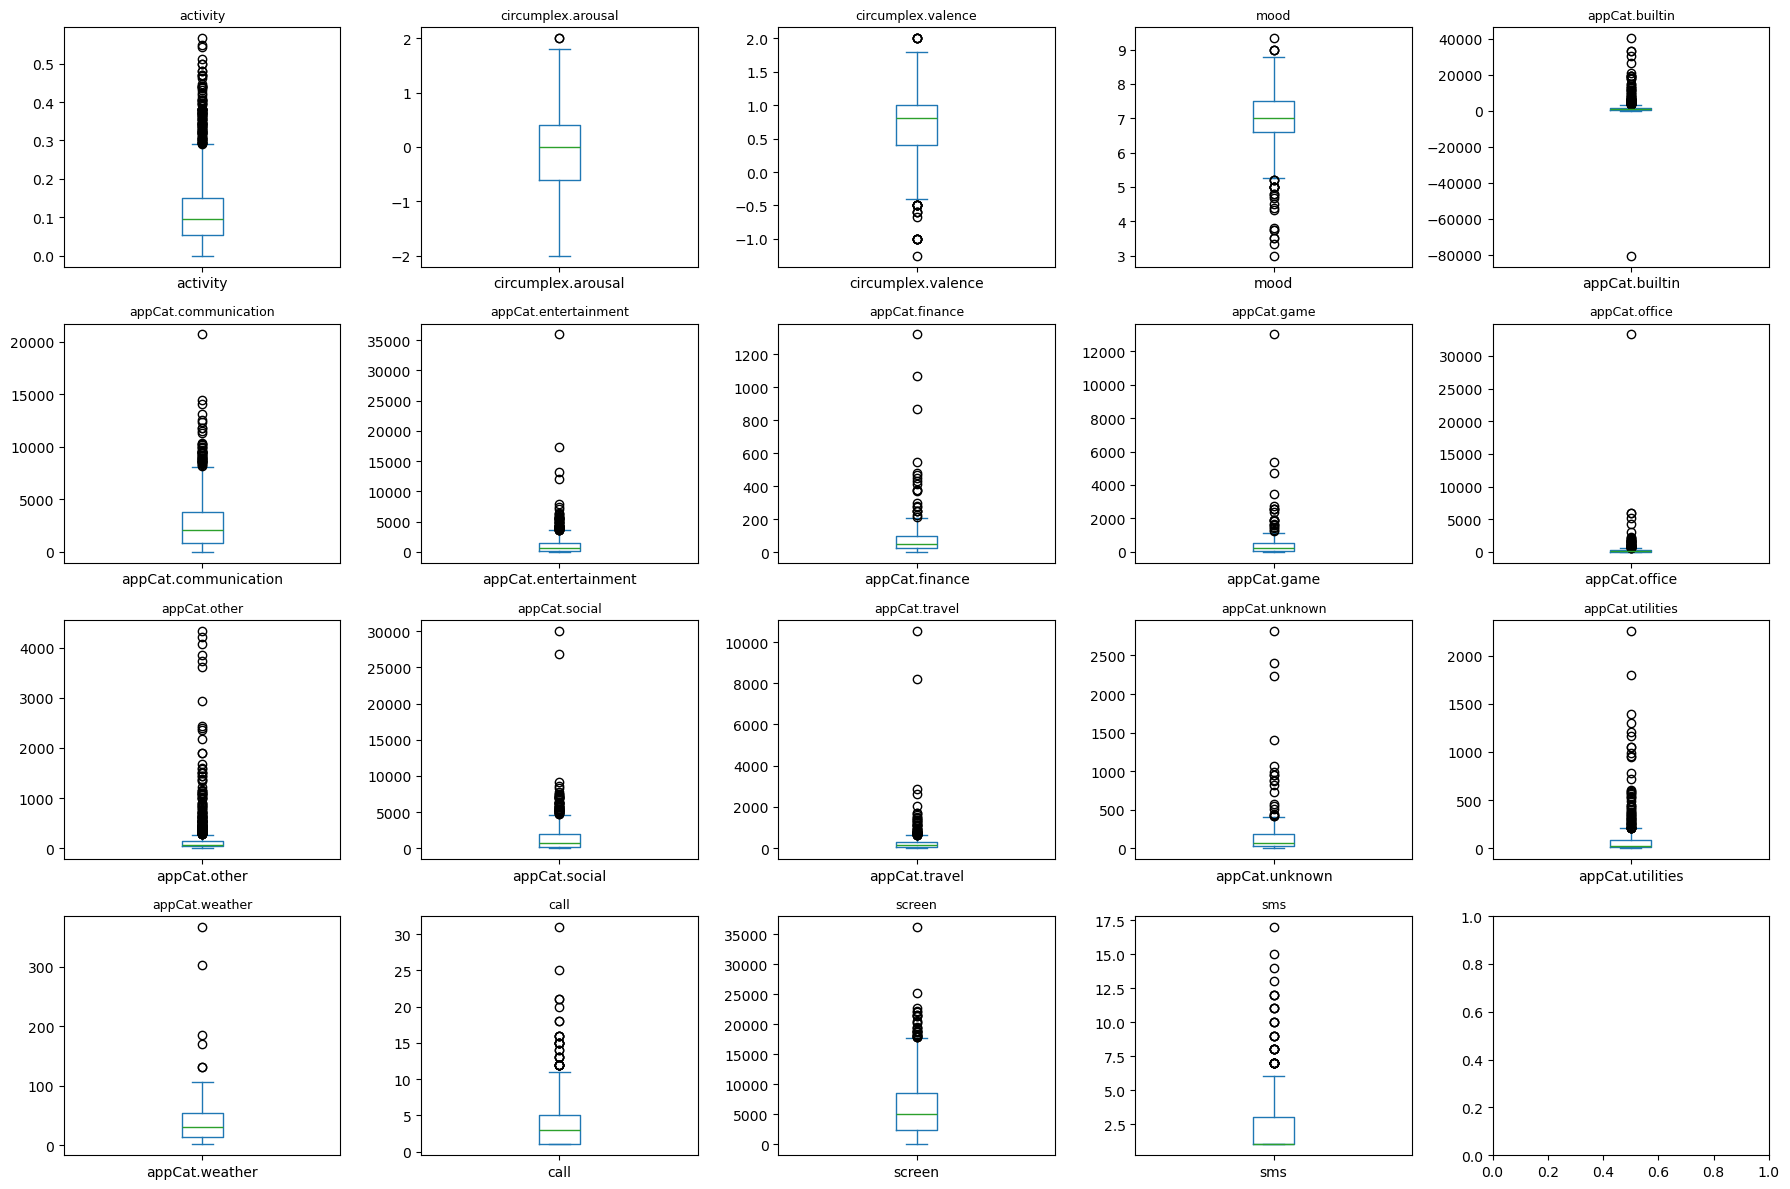

In [25]:
print("####OUTLIERS####")
# Summary with extreme quantiles visible
summary = daily.describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).T
print(summary[['min', '0.1%', '1%', '50%', '99%', '99.9%', 'max']])

# Visual: one boxplot per variable, but variables are on wildly different scales
# so we need one plot per variable OR log-scale
numeric_cols = [c for c in daily.columns if c not in ['id', 'date', 'mood_class']]
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
for ax, col in zip(axes.flat, numeric_cols):
    daily[col].plot(kind='box', ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout(); plt.show()

####MISSINGNESS####
variable
appCat.weather         91.35
appCat.game            85.22
appCat.finance         84.15
appCat.unknown         79.86
appCat.office          78.87
appCat.travel          67.23
appCat.utilities       66.85
sms                    66.62
call                   41.96
appCat.entertainment   35.15
appCat.social          24.50
appCat.other           14.40
appCat.communication    9.65
activity                9.04
appCat.builtin          8.73
screen                  7.81
circumplex.valence      3.06
mood                    2.91
circumplex.arousal      2.91
date                    0.00
id                      0.00
dtype: float64


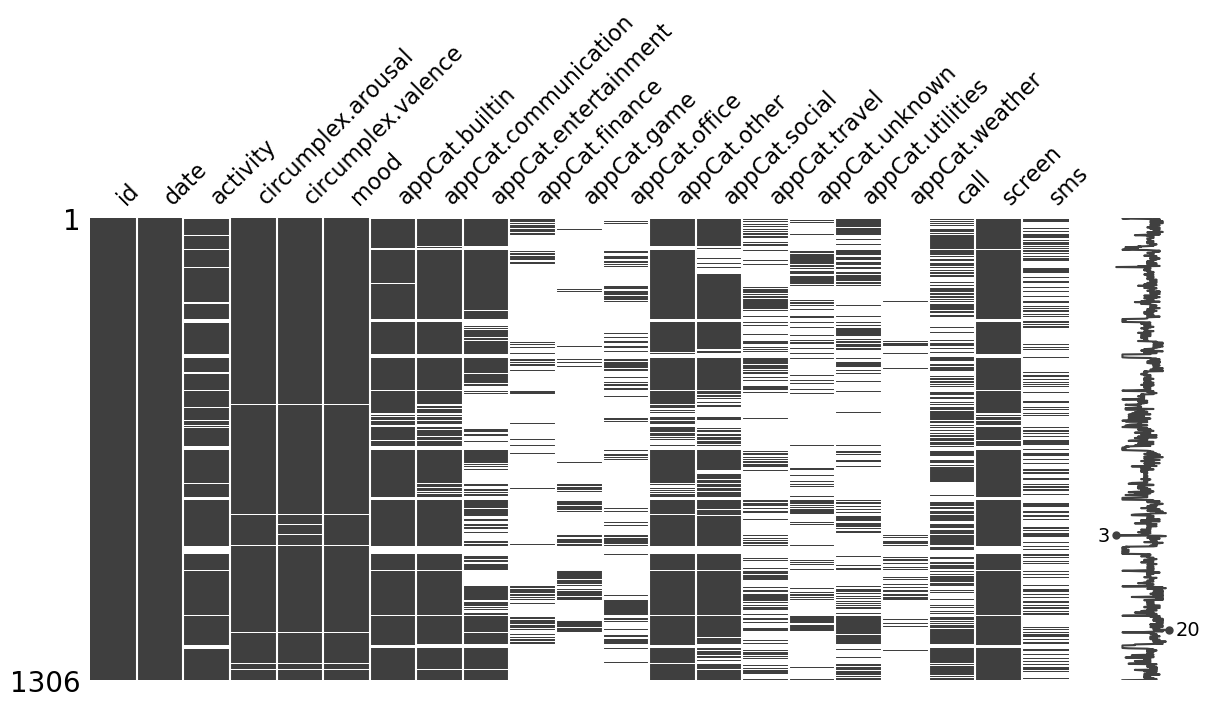

Longest consecutive mood gap per user (days):
id
AS14.23    4
AS14.33    2
AS14.32    2
AS14.14    2
AS14.16    1
AS14.31    1
AS14.29    1
AS14.28    1
AS14.27    1
AS14.26    1
AS14.25    1
AS14.24    1
AS14.01    1
AS14.15    1
AS14.06    1
AS14.03    1
AS14.17    1
AS14.02    0
AS14.19    0
AS14.20    0
AS14.13    0
AS14.12    0
AS14.09    0
AS14.08    0
AS14.07    0
AS14.30    0
AS14.05    0
Name: mood, dtype: int64


In [27]:
print("####MISSINGNESS####")
# How much is missing per variable
missing_pct = daily.isnull().mean().sort_values(ascending=False) * 100
print(missing_pct)

# Pattern of missingness across the (user, day) grid
# Install missingno if you don't have it: pip install missingno
import missingno as msno
# Sort by user so patterns per user are visible
msno.matrix(daily.sort_values(['id', 'date']), figsize=(14, 6))
plt.show()

# Length of consecutive missing runs for mood, per user
def max_gap(series):
    isna = series.isna().astype(int)
    if isna.sum() == 0:
        return 0
    # runs of consecutive NaNs
    groups = (isna != isna.shift()).cumsum()
    return isna.groupby(groups).sum().max()

gaps = daily.groupby('id')['mood'].apply(max_gap).sort_values(ascending=False)
print("Longest consecutive mood gap per user (days):")
print(gaps)

####HISTORY WINDOW####


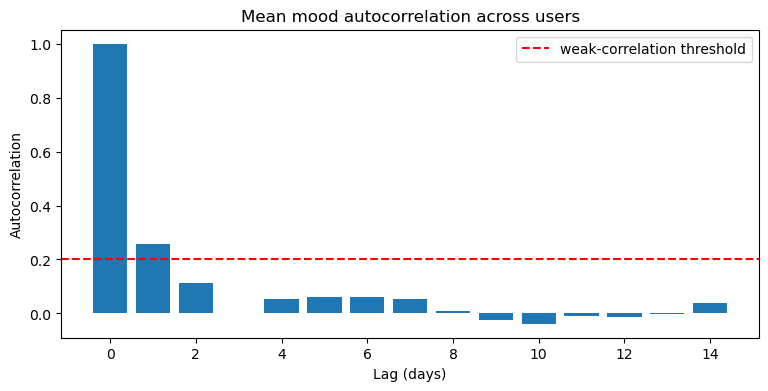

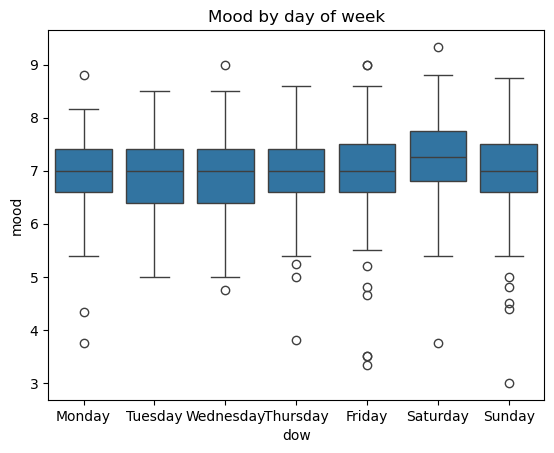

In [31]:
print("####HISTORY WINDOW####")
from statsmodels.tsa.stattools import acf
# Autocorrelation of mood for each user, averaged

max_lag = 14
acf_per_user = []
for uid, g in daily.groupby('id'):
    s = g.set_index('date')['mood'].asfreq('D')  # force daily frequency, NaN for missing
    s = s.interpolate(limit=2)  # small interpolation just to enable ACF
    if s.notna().sum() > max_lag + 5:
        acf_vals = acf(s.dropna(), nlags=max_lag, fft=False)
        acf_per_user.append(acf_vals)

acf_array = np.array(acf_per_user)
mean_acf = acf_array.mean(axis=0)

plt.figure(figsize=(9, 4))
plt.bar(range(len(mean_acf)), mean_acf)
plt.axhline(0.2, color='red', linestyle='--', label='weak-correlation threshold')
plt.xlabel('Lag (days)'); plt.ylabel('Autocorrelation')
plt.title('Mean mood autocorrelation across users')
plt.legend(); plt.show()

# Also: mood by day of week
daily['dow'] = pd.to_datetime(daily['date']).dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=daily, x='dow', y='mood', order=dow_order)
plt.title('Mood by day of week'); plt.show()

####WHICH FEATURES MATTER####
Spearman correlation of today's variables with tomorrow's mood:
variable
mood                    0.48
circumplex.valence      0.27
appCat.entertainment    0.19
appCat.office           0.18
activity                0.16
appCat.other            0.14
appCat.communication    0.11
appCat.unknown         -0.10
appCat.utilities        0.10
screen                  0.09
appCat.weather          0.07
appCat.finance         -0.06
appCat.travel          -0.05
circumplex.arousal      0.04
sms                     0.03
appCat.game             0.03
call                   -0.02
appCat.social           0.01
appCat.builtin          0.00
Name: mood_tomorrow, dtype: float64


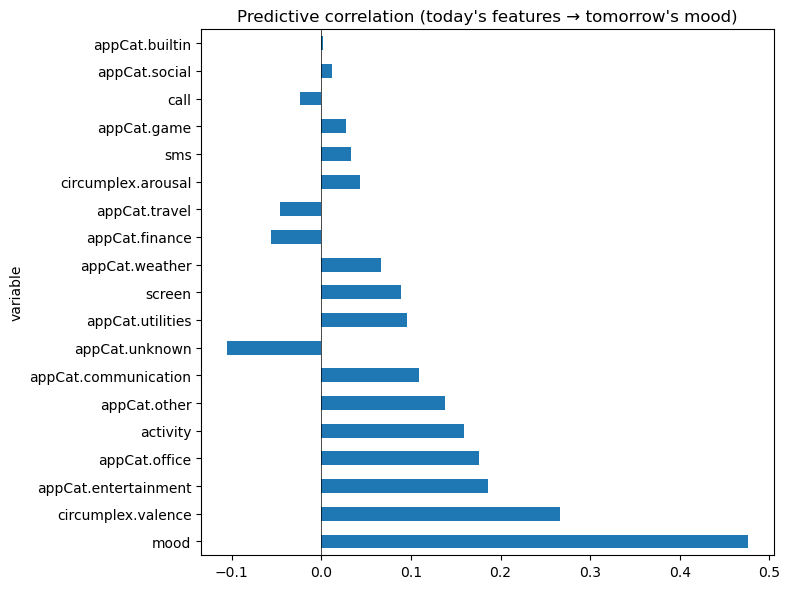

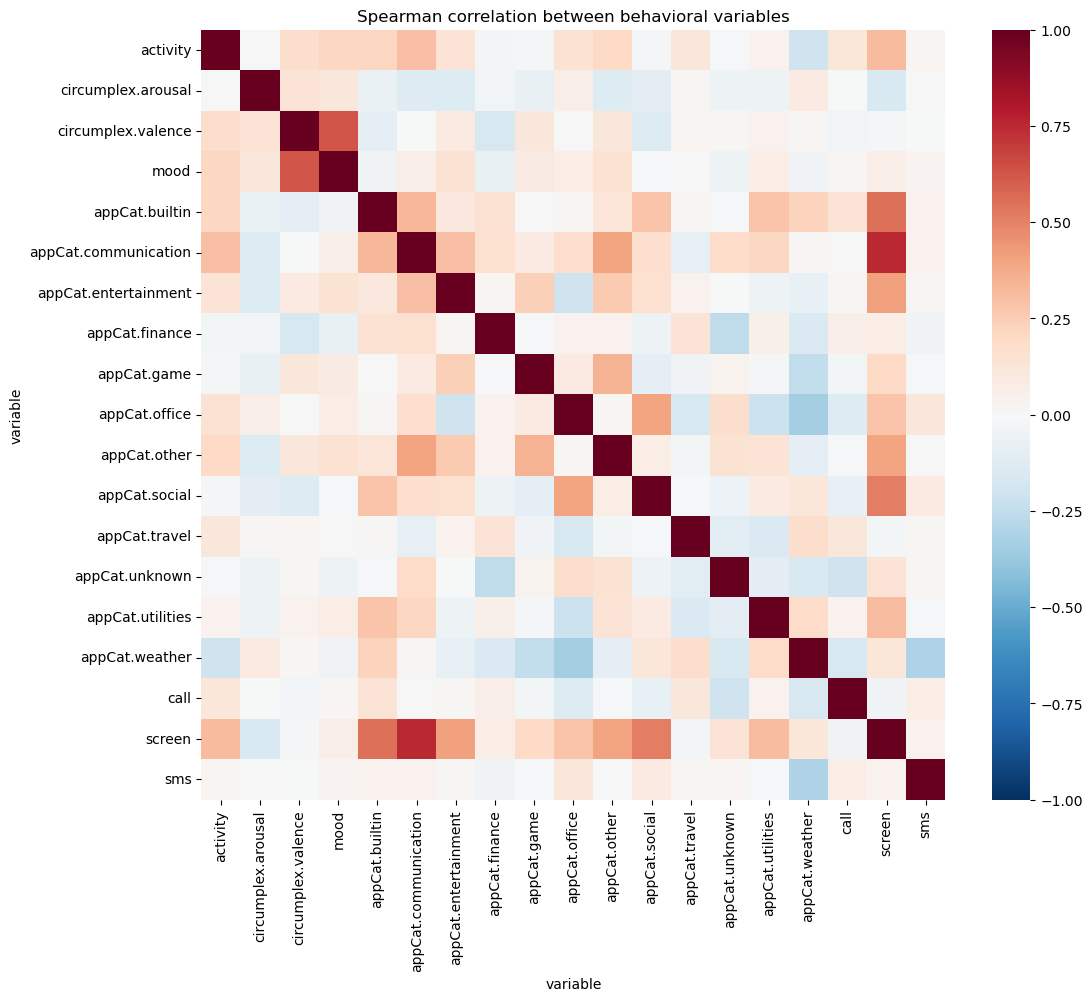

In [32]:
print("####WHICH FEATURES MATTER####")
# Step 1: shift mood by -1 to create "tomorrow's mood", then correlate with today's variables
daily_sorted = daily.sort_values(['id', 'date']).copy()
daily_sorted['mood_tomorrow'] = daily_sorted.groupby('id')['mood'].shift(-1)

feature_cols = [c for c in daily.columns if c not in ['id', 'date', 'mood_class', 'dow']]
corrs = daily_sorted[feature_cols + ['mood_tomorrow']].corr(method='spearman')['mood_tomorrow'].drop('mood_tomorrow')
corrs_sorted = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
print("Spearman correlation of today's variables with tomorrow's mood:")
print(corrs_sorted)

# Visualize
corrs_sorted.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Predictive correlation (today's features → tomorrow's mood)")
plt.tight_layout(); plt.show()

# Also check inter-feature redundancy
plt.figure(figsize=(12, 10))
sns.heatmap(daily[feature_cols].corr(method='spearman'), cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False)
plt.title('Spearman correlation between behavioral variables'); plt.show()

In [33]:
print("####BASELINES####")
# Build the target: tomorrow's mood class (using whatever binning you chose)
daily_sorted['mood_class_tomorrow'] = daily_sorted.groupby('id')['mood_class'].shift(-1)

eval_df = daily_sorted.dropna(subset=['mood_class', 'mood_class_tomorrow'])

# Baseline 1: always predict the majority class
majority = eval_df['mood_class_tomorrow'].mode()[0]
acc_majority = (eval_df['mood_class_tomorrow'] == majority).mean()

# Baseline 2: predict today's class as tomorrow's class (persistence)
acc_persistence = (eval_df['mood_class_tomorrow'] == eval_df['mood_class']).mean()

# Baseline 3: predict each user's personal modal class
user_mode = eval_df.groupby('id')['mood_class_tomorrow'].agg(lambda s: s.mode()[0])
eval_df['pred_user_mode'] = eval_df['id'].map(user_mode)
acc_user_mode = (eval_df['mood_class_tomorrow'] == eval_df['pred_user_mode']).mean()

print(f"Majority-class baseline:   {acc_majority:.3f}")
print(f"Persistence baseline:      {acc_persistence:.3f}")
print(f"Per-user modal baseline:   {acc_user_mode:.3f}")

# Also compute macro-F1 for all three
from sklearn.metrics import f1_score
y_true = eval_df['mood_class_tomorrow']
print(f"Majority F1-macro:   {f1_score(y_true, [majority]*len(y_true), average='macro'):.3f}")
print(f"Persistence F1-macro:{f1_score(y_true, eval_df['mood_class'], average='macro'):.3f}")
print(f"User-mode F1-macro:  {f1_score(y_true, eval_df['pred_user_mode'], average='macro'):.3f}")

####BASELINES####


KeyError: 'Column not found: mood_class'

In [20]:
# Make sure the data is sorted by user and date before we loop through it
daily_mood = daily_mood2.sort_values(["id", "date"])

# --- (3a) Autocorrelation: does today's mood predict tomorrow's? -----------
# For each user, we pair up (mood today, mood tomorrow) and see how
# correlated those pairs are. A high number means mood is "sticky."

autocorr_per_user = {}

for user_id, group in daily_mood.groupby("id"):
    moods = group["mood_daily"].values  # this user's moods in date order

    if len(moods) >= 3:
        today = moods[:-1]      # all moods except the last one
        tomorrow = moods[1:]    # all moods except the first one
        correlation = np.corrcoef(today, tomorrow)[0, 1]
        autocorr_per_user[user_id] = correlation

autocorr_values = list(autocorr_per_user.values())
print("=== Autocorrelation of mood (today vs tomorrow) ===")
print(f"Average across users: {np.mean(autocorr_values):.3f}")
print(f"Min: {np.min(autocorr_values):.3f}, Max: {np.max(autocorr_values):.3f}")

=== Autocorrelation of mood (today vs tomorrow) ===
Average across users: 0.236
Min: -0.154, Max: 0.626


In [22]:
# --- (3b) Baseline 1: "predict tomorrow = today" --------------------------
# For every pair of consecutive days, the error is |tomorrow - today|.
# Average those errors to get the MAE of this simple baseline.

all_errors = []

for user_id, group in daily_mood.groupby("id"):
    moods = group["mood_daily"].values
    for i in range(len(moods) - 1):
        error = abs(moods[i + 1] - moods[i])
        all_errors.append(error)

persistence_mae = np.mean(all_errors)
print(f"\nPersistence baseline MAE: {persistence_mae:.3f}")

# --- (3c) Baseline 2: "always predict the overall average mood" ----------
overall_mean = daily_mood["mood_daily"].mean()
mean_baseline_errors = abs(daily_mood["mood_daily"] - overall_mean)
mean_baseline_mae = mean_baseline_errors.mean()
print(f"Mean-baseline MAE: {mean_baseline_mae:.3f}")



Persistence baseline MAE: 0.553
Mean-baseline MAE: 0.543


In [23]:
# --- (4) Do users have different mood baselines? -------------------------
# For each user, compute their mean mood and their std (spread).
user_means = []
user_stds = []

for user_id, group in daily_mood.groupby("id"):
    user_means.append(group["mood_daily"].mean())
    user_stds.append(group["mood_daily"].std())

print("\n=== Between-user differences ===")
print(f"User means range from {min(user_means):.2f} to {max(user_means):.2f}")
print(f"Standard deviation of user means (between-user spread): {np.std(user_means):.2f}")
print(f"Average within-user std (how much each user bounces around): {np.mean(user_stds):.2f}")


=== Between-user differences ===
User means range from 6.01 to 7.78
Standard deviation of user means (between-user spread): 0.39
Average within-user std (how much each user bounces around): 0.61
